**Homework 4**

В этом ноутбуке строю модели линейной регрессии (с регуляризацией и без), которые будут предсказывать цену подержанной Тойоты Короллы. Датасет: https://www.kaggle.com/datasets/vishakhdapat/price-of-used-toyota-corolla-cars, Он состоит из 1436 записей и 39 признаков с таргетом Price 

In [225]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import kstest, norm
from collections import Counter

df = pd.read_csv('ToyotaCorolla.csv')
df.head()

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0


**1) EDA**

In [226]:
print(df.describe())
print(df.info())
print(df.isnull().sum())

                Id         Price    Age_08_04    Mfg_Month     Mfg_Year  \
count  1436.000000   1436.000000  1436.000000  1436.000000  1436.000000   
mean    721.555014  10730.824513    55.947075     5.548747  1999.625348   
std     416.476890   3626.964585    18.599988     3.354085     1.540722   
min       1.000000   4350.000000     1.000000     1.000000  1998.000000   
25%     361.750000   8450.000000    44.000000     3.000000  1998.000000   
50%     721.500000   9900.000000    61.000000     5.000000  1999.000000   
75%    1081.250000  11950.000000    70.000000     8.000000  2001.000000   
max    1442.000000  32500.000000    80.000000    12.000000  2004.000000   

                  KM           HP    Met_Color    Automatic           CC  ...  \
count    1436.000000  1436.000000  1436.000000  1436.000000   1436.00000  ...   
mean    68533.259749   101.502089     0.674791     0.055710   1576.85585  ...   
std     37506.448872    14.981080     0.468616     0.229441    424.38677  ...   


<Axes: >

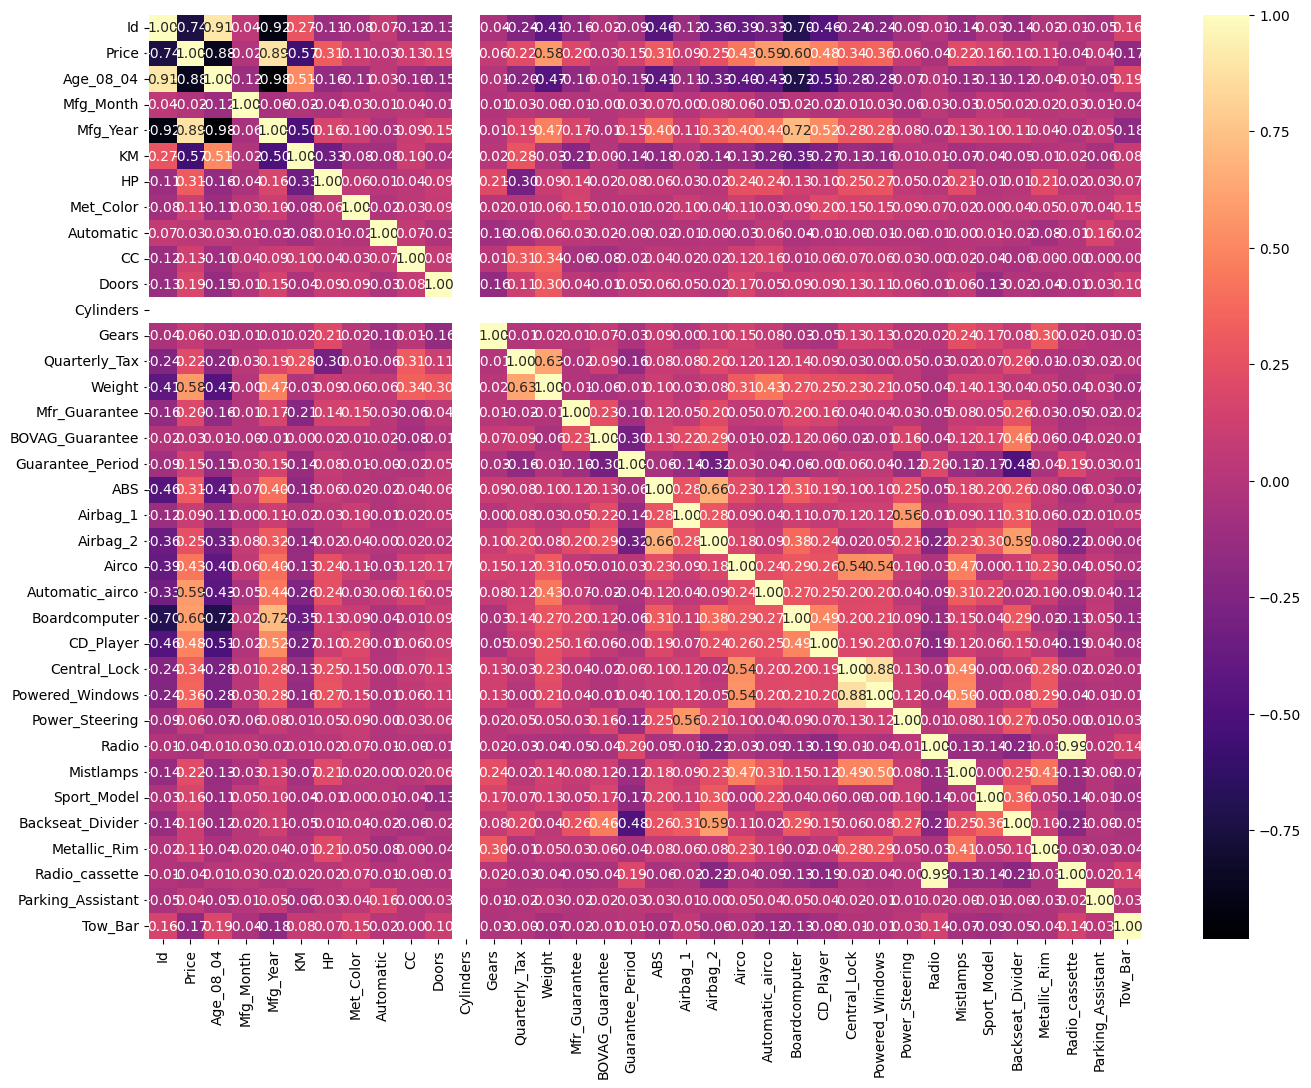

In [227]:
plt.figure(figsize=(16,12))
sns.heatmap(df.select_dtypes("number").corr(), annot=True, cmap='magma', fmt='.2f')

Text(0.5, 1.0, 'Correlation of Num Features with Target')

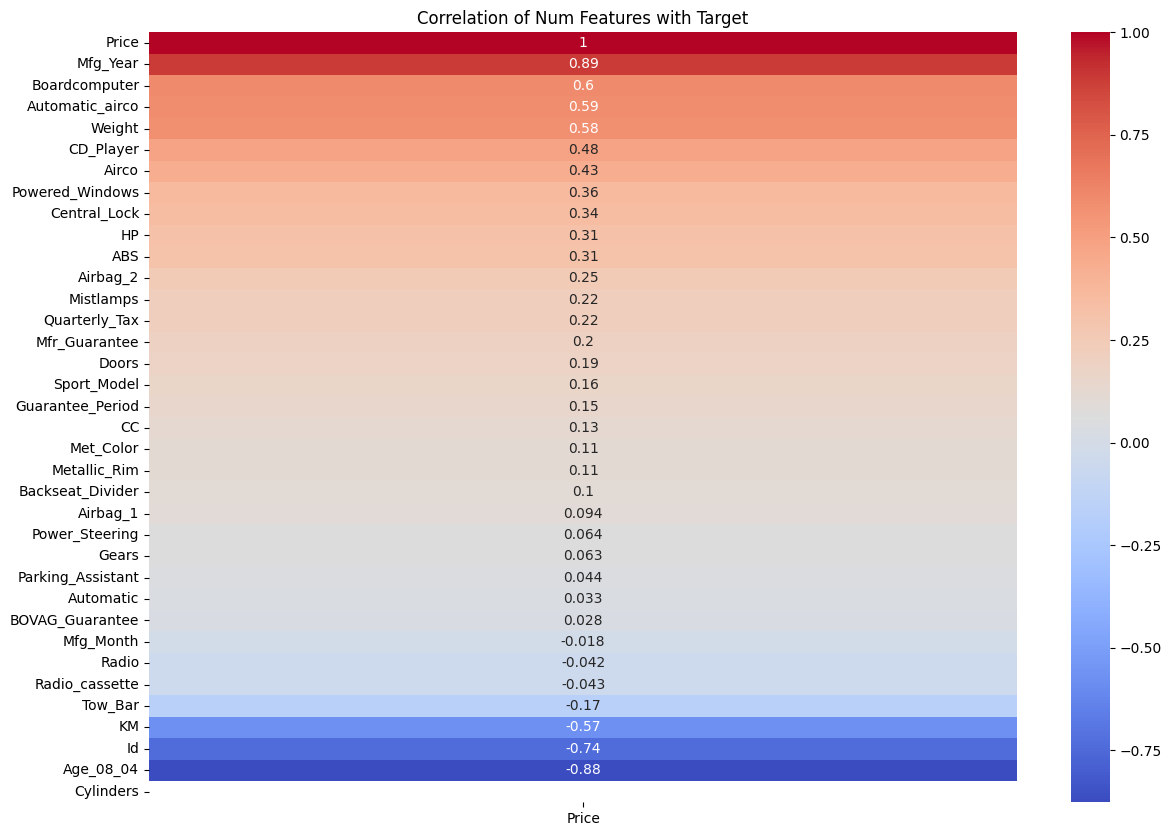

In [228]:
plt.figure(figsize=(14,10))
sns.heatmap(df.select_dtypes("number").corr()[["Price"]].sort_values("Price", ascending=False), 
            annot=True, cmap="coolwarm")
plt.title("Correlation of Num Features with Target")

In [229]:
df['Model'].nunique()

319

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35],
 [Text(0, 0, 'Id'),
  Text(1, 0, 'Price'),
  Text(2, 0, 'Age_08_04'),
  Text(3, 0, 'Mfg_Month'),
  Text(4, 0, 'Mfg_Year'),
  Text(5, 0, 'KM'),
  Text(6, 0, 'HP'),
  Text(7, 0, 'Met_Color'),
  Text(8, 0, 'Automatic'),
  Text(9, 0, 'CC'),
  Text(10, 0, 'Doors'),
  Text(11, 0, 'Cylinders'),
  Text(12, 0, 'Gears'),
  Text(13, 0, 'Quarterly_Tax'),
  Text(14, 0, 'Weight'),
  Text(15, 0, 'Mfr_Guarantee'),
  Text(16, 0, 'BOVAG_Guarantee'),
  Text(17, 0, 'Guarantee_Period'),
  Text(18, 0, 'ABS'),
  Text(19, 0, 'Airbag_1'),
  Text(20, 0, 'Airbag_2'),
  Text(21, 0, 'Airco'),
  Text(22, 0, 'Automatic_airco'),
  Text(23, 0, 'Boardcomputer'),
  Text(24, 0, 'CD_Player'),
  Text(25, 0, 'Central_Lock'),
  Text(26, 0, 'Powered_Windows'),
  Text(27, 0, 'Power_Steering'),
  Text(28, 0, 'Radio'),
  Text

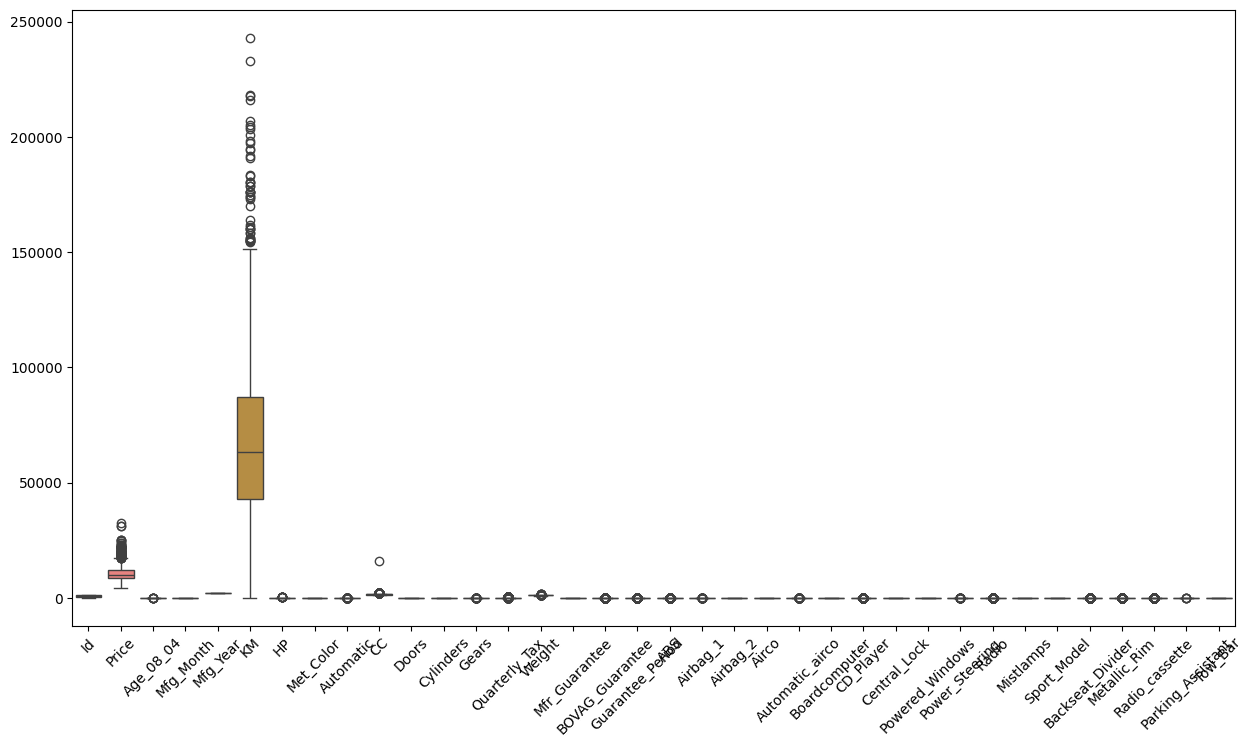

In [230]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df)
plt.xticks(rotation=45)

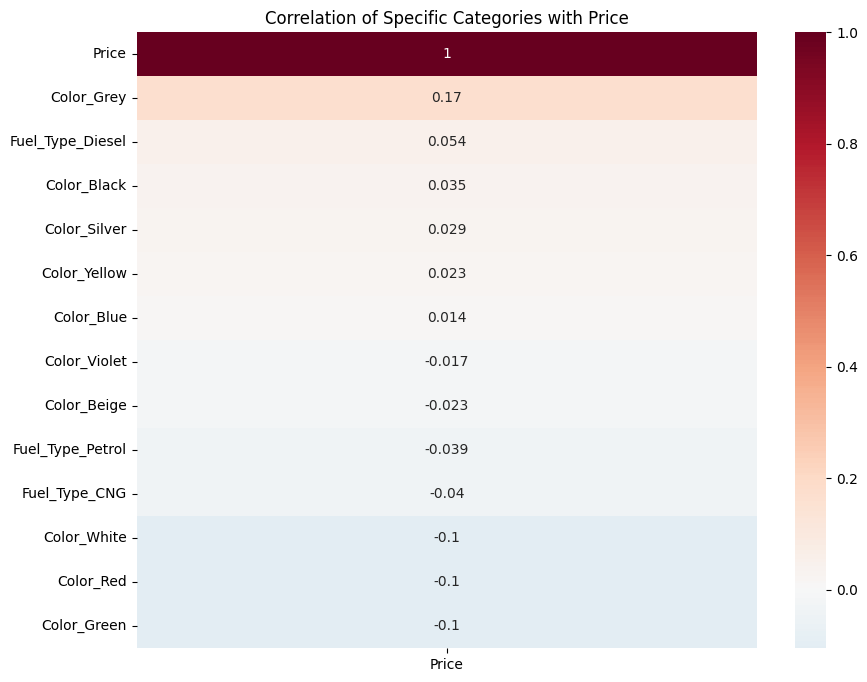

In [231]:
categorical_cols = ['Fuel_Type', 'Color']
target = 'Price'

df_encoded = pd.get_dummies(df[[target] + categorical_cols])

corr_matrix = df_encoded.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix[[target]].sort_values(by=target, ascending=False), 
            annot=True, cmap='RdBu_r', center=0)

plt.title('Correlation of Specific Categories with Price')
plt.show()

В результатах .describe() увидел, что у некоторых bool фич (со значениями либо 0 либо 1, в частности говорю про Паркинг_ассистант и Павер_стилинг) среднее очень близко к 0 или 1 (0.02 и 0.97), что значит большой перевес значений 0 или 1 по количеству. Настолько большая вариативность (если больше 95%, например) не будет полезной для модели при обучении, по этому решил проверить какие из фич имеют такое распределение значений

In [232]:
print(f'{"Признак":<22} {"Доля":>10}')
print('-' * 58)

for col in df.select_dtypes('number').columns:
    top_val = df[col].value_counts(normalize=True).iloc[0]
    
    if top_val > 0.95:  
        print(f'{col:<22}{top_val:>9.1%}')

Признак                      Доля
----------------------------------------------------------
Cylinders                100.0%
Gears                     96.8%
Airbag_1                  97.1%
Power_Steering            97.8%
Parking_Assistant         99.7%


**Промежуточные выводы:**

1. Пропусков нет, 1436 записей, 39 признаков.
2. Почти все признаки нумерические, категориальных 3: Model (319 значений (слишком много для one hot encoder)), Fuel_Type (3 значения), Color (10 значений).
3. Age_08_04 и Mfg_Year коррелируют на −0.984. Оставляю Age_08_04 (т.к. он обратно коррелирует к таргету и в целом удобнее для использования).
4. Из хитмапа видно, что Cylinders — константа
5. Gears, Airbag_1, Power_steeling и Parking assistant в более чем 90% случаев имеют одно значение (+ их корреляция с таргетом - до 0.1)
6. Id - порядковый номер; из-за удачного распределения имеет высокую корреляцию -0.76, но сам не несет смысловой нагрузки
7. Radio и Radio_cassette коррелируют на 0.992, Central_Lock и Powered_Windows — на 0.876 - мультиколлинеарные признаки
8. Самые сильные предикторы: Age_08_04 (−0.88), Boardcomputer (0.60), Automatic_airco (0.59), Weight (0.58), KM (−0.57).

**2) Feature Engeneering**

Сперва очищаем датафрейм от констант, мультиколлинеарных или маловлияющих фич

In [233]:
df_clean = df.copy()

unnessessary = ['Id', 'Model']
constant = ['Cylinders']
multicollinear = ['Mfg_Year', 'Powered_Windows', 'Radio', 'Radio_cassette']
weak = ['Mfg_Month', 'BOVAG_Guarantee', 'Automatic',
             'Met_Color', 'Metallic_Rim', 'Backseat_Divider',
             'Guarantee_Period', 'Sport_Model', 'Doors', 'CC', 'Mfr_Guarantee',
             'Gears', 'Airbag_1', 'Power_Steering', 'Parking_Assistant', 'Color']

all_to_drop = unnessessary + constant + multicollinear + weak
df_clean = df_clean.drop(columns=all_to_drop)

df_clean = pd.get_dummies(df_clean,dtype=int, drop_first=True)
print(df_clean.head())

   Price  Age_08_04     KM  HP  Quarterly_Tax  Weight  ABS  Airbag_2  Airco  \
0  13500         23  46986  90            210    1165    1         1      0   
1  13750         23  72937  90            210    1165    1         1      1   
2  13950         24  41711  90            210    1165    1         1      0   
3  14950         26  48000  90            210    1165    1         1      0   
4  13750         30  38500  90            210    1170    1         1      1   

   Automatic_airco  Boardcomputer  CD_Player  Central_Lock  Mistlamps  \
0                0              1          0             1          0   
1                0              1          1             1          0   
2                0              1          0             0          0   
3                0              1          0             0          0   
4                0              1          0             1          1   

   Tow_Bar  Fuel_Type_Diesel  Fuel_Type_Petrol  
0        0                 1         

Дальше мы улучшаем оставшиеся фичи. По логике, возраст машины и размер пробега имеют не совсем линейное влияние на цену: хоть общая тенденция и наблюдается, разница между 0 и 10к км, и между 140 и 150к км пробега будут иметь разное влияение на цену: в первом случае влияние будет на цену большое (машина с новой превратилась в немного использованную), а в другой - минимальным (статус много использованной машины в глазах покупателя не поменялся). И та же логика прослеживается с возрастом авто.

Я протестил и логарифмирование, и взятие под корень обоих фич:

In [234]:
df_clean['sqrt_Age'] = np.sqrt(df['Age_08_04'])
df_clean['sqrt_KM'] = np.sqrt(df['KM'])
df_clean['log_Age'] = np.log1p(df['Age_08_04'])
df_clean['log_KM'] = np.log1p(df['KM'])

Text(0.5, 1.0, 'Engeeneered dataset Correlation with Target')

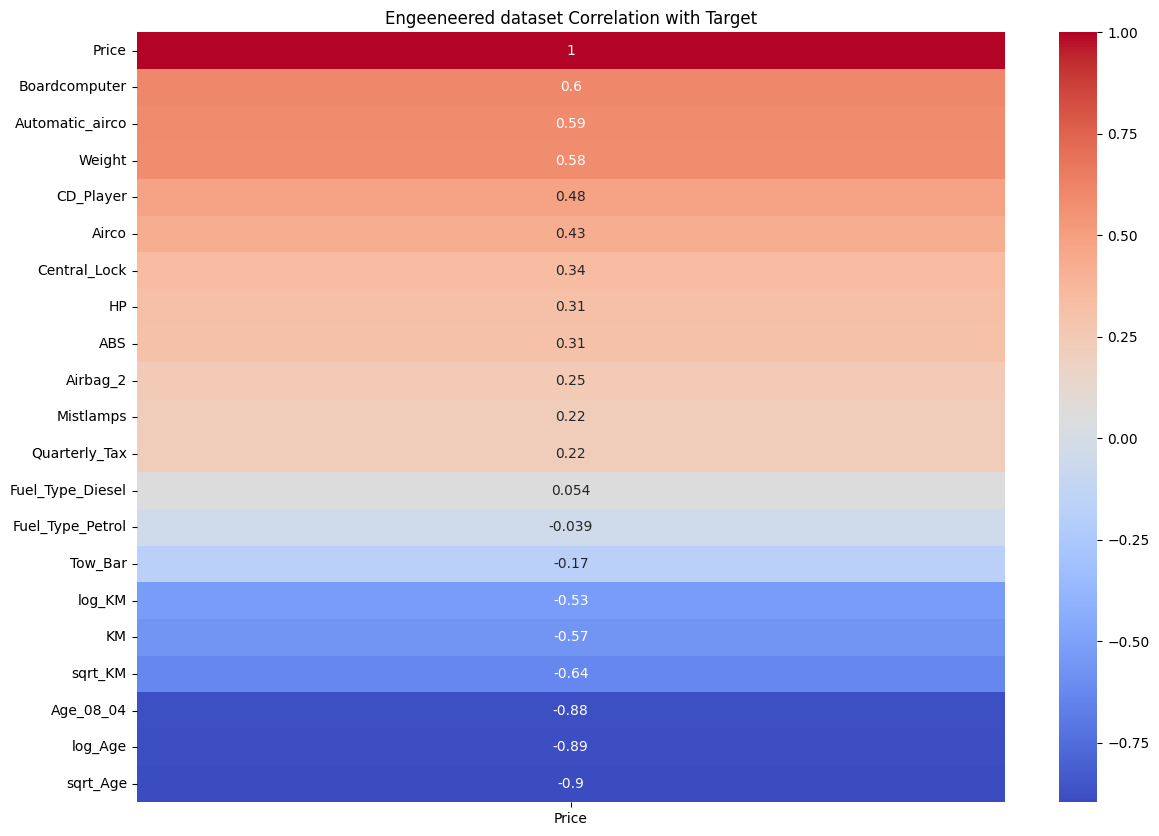

In [235]:
plt.figure(figsize=(14,10))
sns.heatmap(df_clean.select_dtypes("number").corr()[["Price"]].sort_values("Price", ascending=False), 
            annot=True, cmap="coolwarm")
plt.title("Engeeneered dataset Correlation with Target")

Как видно, функция квадратного корня дает лучшие результаты корреляции и для Age,и для KM

In [236]:
to_drop = ["KM", "Age_08_04", "log_KM", "log_Age" ]
df_clean = df_clean.drop(columns=to_drop)


**3) Разделение выборки и масштабирование**

In [237]:
X = df_clean.drop("Price", axis=1).values
y = df_clean["Price"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (1148, 16)
Test shape: (288, 16)


Выборку разделил на 20% test и 80% train,а также масштабировал, так как у разных фич масштабы значени отличаются очень сильно (показал на сравнениях значений боксплотами)

Разделение выборки происходит чтобы избежать data leackage и обьективно протестировать обобщающую спобосность модели (проверка переобучения). Масштабирование, в свою очередь, нужно чтобы исбежать перевешивания влияния больших значений фич (так как на резльтат влияет сумма домноженных на весы значений фич)

**4) Обучение моделей**



Обучаю базовую модель линейной регрессии, а потом модели с регуляризациями Ridge и Lasso с подбором гиперпараметра альфа через GridSearchCV

Проверив опытным путем, решил встроить StandardScaler в каждый pipeline после PolynomialFeatures (в других конфигурациях точность получалась меньше)

In [238]:
start_time_linear = time.time()

linear_reg = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('scalar', StandardScaler()),
    ('linear', LinearRegression())
])
linear_reg.fit(X_train, y_train)


y_pred_linear_train = linear_reg.predict(X_train)
y_pred_linear_test = linear_reg.predict(X_test)

r2_score_linear_train = r2_score(y_train, y_pred_linear_train)
r2_score_linear_test = r2_score(y_test, y_pred_linear_test)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear_test))
mape_linear = mean_absolute_percentage_error(y_test, y_pred_linear_test)
cv_linear = cross_val_score(estimator=linear_reg, X=X_train, y=y_train, cv=10)

linear_time = time.time() - start_time_linear

print("Linear Regression Results:")
print("CV Mean: ", cv_linear.mean())
print('R2_score (train): ', r2_score_linear_train)
print('R2_score (test): ', r2_score_linear_test)
print("RMSE: ", rmse_linear)
print("MAPE: ", mape_linear)
print("Time: ", linear_time)


Linear Regression Results:
CV Mean:  0.8567339753175307
R2_score (train):  0.9341199458751515
R2_score (test):  0.7073341442914116
RMSE:  1976.1018988101262
MAPE:  0.08466242539645516
Time:  0.26477479934692383


In [239]:
start_time_ridge = time.time()

ridge_steps = [
    ('poly', PolynomialFeatures(degree=2)),
    ('scalar', StandardScaler()),
    ('model', Ridge())
]
ridge_pipe = Pipeline(ridge_steps)

ridge_param_grid = {'model__alpha': [0.1, 1.0, 10.0, 100.0, 500.0, 1000.0]}
ridge_grid = GridSearchCV(ridge_pipe, ridge_param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train, y_train.ravel())

best_ridge = ridge_grid.best_estimator_
print(f"Лучший параметр alpha для Ridge: {ridge_grid.best_params_['model__alpha']}")

y_pred_ridge_train = best_ridge.predict(X_train)
y_pred_ridge_test = best_ridge.predict(X_test)

r2_score_ridge_train = r2_score(y_train, y_pred_ridge_train)
r2_score_ridge_test = r2_score(y_test, y_pred_ridge_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge_test))
mape_ridge = mean_absolute_percentage_error(y_test, y_pred_ridge_test)
cv_ridge = cross_val_score(estimator=best_ridge, X=X_train, y=y_train.ravel(), cv=10).mean()

ridge_time = time.time() - start_time_ridge

print("Ridge Regression Results:")
print(f"R2 Score (train): {r2_score_ridge_train:.4f}")
print(f"R2 Score (test): {r2_score_ridge_test:.4f}")
print(f"RMSE: {rmse_ridge:.2f}")
print(f"MAPE: {mape_ridge:.4f}")
print(f"CV mean: {cv_ridge:.4f}")
print("Time: ", ridge_time)


Лучший параметр alpha для Ridge: 100.0
Ridge Regression Results:
R2 Score (train): 0.9170
R2 Score (test): 0.9108
RMSE: 1090.82
MAPE: 0.0790
CV mean: 0.8934
Time:  0.39969825744628906


In [240]:
start_time_lasso = time.time()

lasso_steps = [
    ('poly', PolynomialFeatures(degree=2)),
    ('scalar', StandardScaler()),
    ('model', Lasso(max_iter=5000))
]
lasso_pipe = Pipeline(lasso_steps)

lasso_param_grid = {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 500.0]}
lasso_grid = GridSearchCV(lasso_pipe, lasso_param_grid, cv=5, scoring='neg_mean_squared_error')
lasso_grid.fit(X_train, y_train.ravel())

best_lasso = lasso_grid.best_estimator_
print(f"Лучший параметр alpha для Lasso: {lasso_grid.best_params_['model__alpha']}")

y_pred_lasso_train = best_lasso.predict(X_train)
y_pred_lasso_test = best_lasso.predict(X_test)

r2_score_lasso_train = r2_score(y_train, y_pred_lasso_train)
r2_score_lasso_test = r2_score(y_test, y_pred_lasso_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso_test))
mape_lasso = mean_absolute_percentage_error(y_test, y_pred_lasso_test)
cv_lasso = cross_val_score(estimator=best_lasso, X=X_train, y=y_train.ravel(), cv=10).mean()

lasso_time = time.time() - start_time_lasso


print("Lasso Regression Results:")
print(f"R2 Score (train): {r2_score_lasso_train:.4f}")
print(f"R2 Score (test): {r2_score_lasso_test:.4f}")
print(f"RMSE: {rmse_lasso:.2f}")
print(f"MAPE: {mape_lasso:.4f}")
print(f"CV mean: {cv_lasso:.4f}")
print("Time: ", lasso_time)


c:\Coding Projects\ml-course-homeworks\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.729e+08, tolerance: 1.213e+06
  model = cd_fast.enet_coordinate_descent(
c:\Coding Projects\ml-course-homeworks\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.486e+08, tolerance: 1.145e+06
  model = cd_fast.enet_coordinate_descent(
c:\Coding Projects\ml-course-homeworks\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider

Лучший параметр alpha для Lasso: 10.0
Lasso Regression Results:
R2 Score (train): 0.9197
R2 Score (test): 0.9112
RMSE: 1088.68
MAPE: 0.0789
CV mean: 0.8949
Time:  3.113085985183716


Линейная регрессия обучилась быстрее всего (0.25 с). Ridge чуть медленнее (0.4 с) из-за подбора гипермараметра alpha в GridSearchCV (т.к. модель обучается по 5 раз на каждой альфе), но каждое отдельное обучение тоже имеет closed-form решение. Lasso — самая медленная модель (3с), поскольку использует итеративный координатный спуск и тоже проходит через GridSearchCV;


**5) Оценка качества и сравнение моделей**

Использую следующие метрики:
- **RMSE** (Root Mean Squared Error) — основная метрика; измеряется в тех же единицах, что и цена (евро), и сильнее штрафует большие ошибки, что важно при предсказании цен.
- **MAPE** (Mean Absolute Percentage Error) — показывает среднюю ошибку в процентах от реальной цены, удобна для интерпретации.
- **R²** — доля дисперсии целевой переменной, объяснённая моделью. Позволяет понять, насколько модель лучше «тупого» предсказания средним.

In [241]:
def analyze_residuals(residuals, y_pred):
  # 1. Гистограмма остатков
  plt.figure(figsize=(8, 5))
  plt.hist(residuals, bins=30, color='blue', alpha=0.7, edgecolor='black')
  plt.title('Гистограмма распределения остатков')
  plt.xlabel('Значения остатков')
  plt.ylabel('Частота')
  plt.show()

  # 2. Проверка гипотезы о нормальности остатков (Критерий Колмогорова-Смирнова)
  residuals_mean = np.mean(residuals)
  residuals_std = np.std(residuals)
  theoretical_distribution = norm(loc=residuals_mean, scale=residuals_std)

  statistic, p_value = kstest(residuals, theoretical_distribution.cdf)
  print(f"Статистика Колмогорова-Смирнова: {statistic:.4f}, P-значение: {p_value:.4F}")

  alpha = 0.05
  if p_value < alpha:
      print("Гипотеза о нормальном распределении остатков ОТКЛОНЯЕТСЯ (остатки не нормальны).")
  else:
      print("Гипотеза о нормальном распределении остатков ПРИНИМАЕТСЯ.")

  # 3. Диаграмма рассеяния: Остатки vs Прогнозы
  plt.figure(figsize=(8,5))
  plt.scatter(y_pred.ravel(), residuals, alpha=0.5)
  plt.axhline(y=0, color='r', linestyle='--')
  plt.title('Зависимость остатков от предсказанных значений (Homoscedasticity check)')
  plt.xlabel("Предсказанные значения (y_hat)")
  plt.ylabel("Остатки (residuals)")
  plt.show()


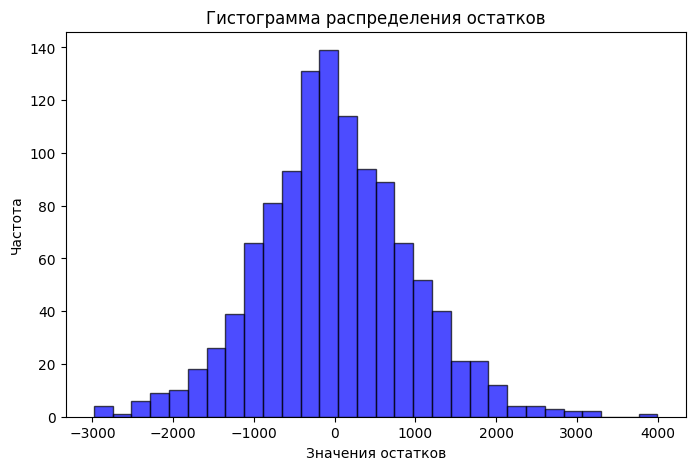

Статистика Колмогорова-Смирнова: 0.0300, P-значение: 0.2483
Гипотеза о нормальном распределении остатков ПРИНИМАЕТСЯ.


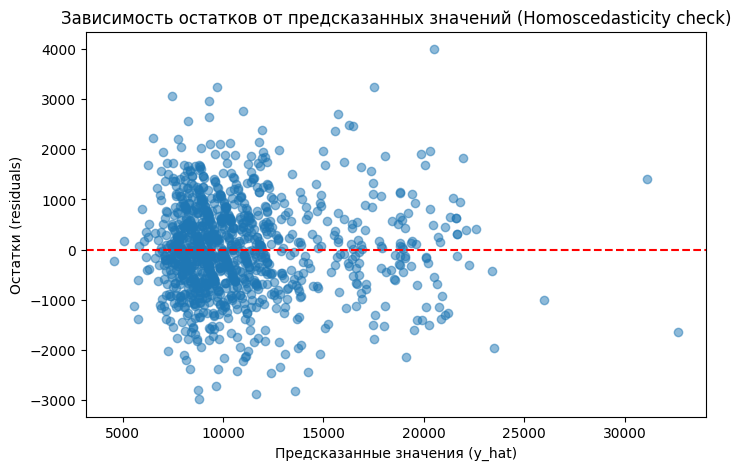

In [242]:
residuals = (y_train.ravel() - y_pred_linear_train.ravel())
analyze_residuals(residuals, y_pred_linear_train)

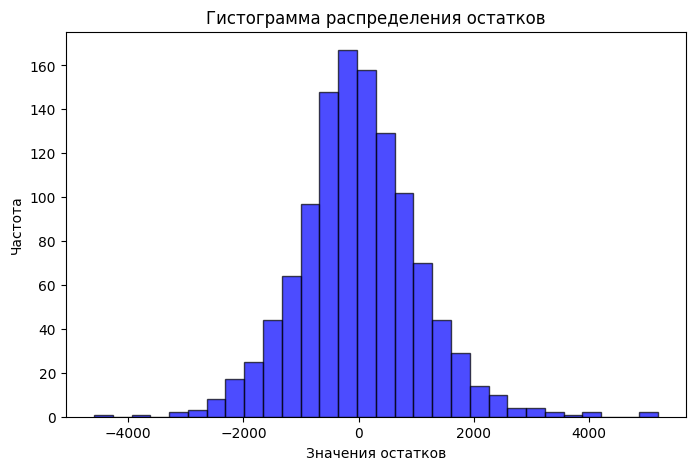

Статистика Колмогорова-Смирнова: 0.0345, P-значение: 0.1279
Гипотеза о нормальном распределении остатков ПРИНИМАЕТСЯ.


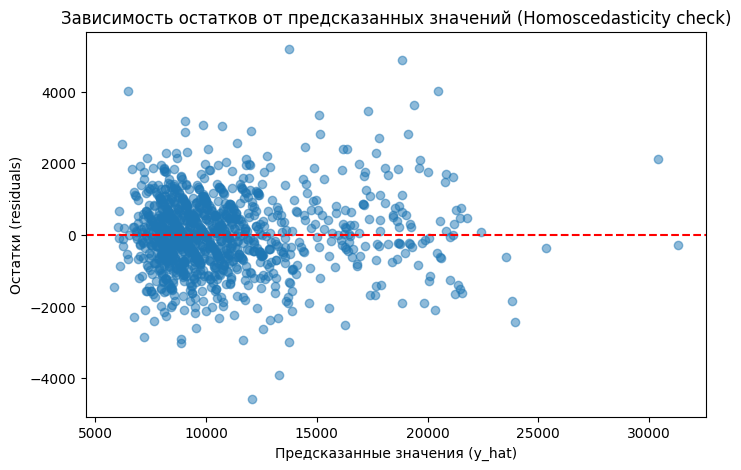

In [243]:
residuals_ridge = (y_train.ravel() - y_pred_ridge_train.ravel())
analyze_residuals(residuals_ridge, y_pred_ridge_train)

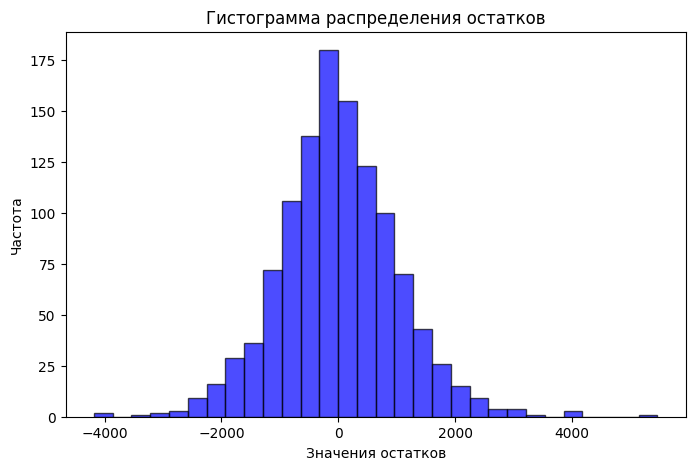

Статистика Колмогорова-Смирнова: 0.0350, P-значение: 0.1168
Гипотеза о нормальном распределении остатков ПРИНИМАЕТСЯ.


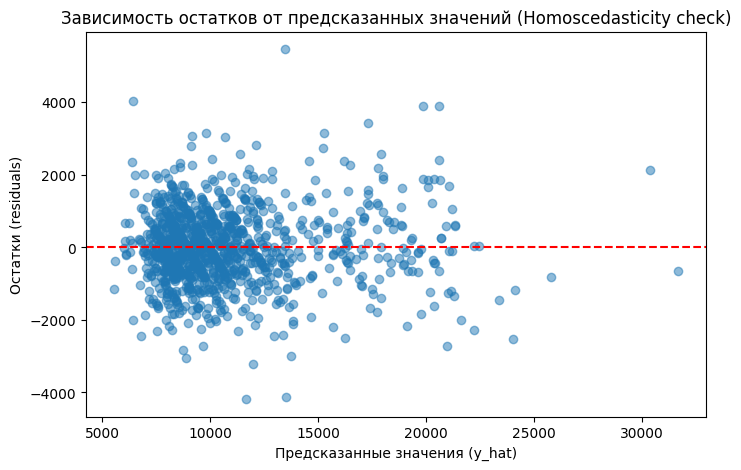

In [244]:
residuals_lasso = (y_train.ravel() - y_pred_lasso_train.ravel())
analyze_residuals(residuals_lasso, y_pred_lasso_train)

In [245]:
results = pd.DataFrame({
    'Model': ['Linear', 'Ridge', 'Lasso'],
    'R2_train': [r2_score_linear_train, r2_score_ridge_train, r2_score_lasso_train],
    'R2_test': [r2_score_linear_test, r2_score_ridge_test, r2_score_lasso_test],
    'RMSE_test': [rmse_linear, rmse_ridge, rmse_lasso],
    'MAPE_test': [mape_linear, mape_ridge, mape_lasso],
    'Time_sec': [linear_time, ridge_time, lasso_time]
})
print(results.to_string(index=False))

 Model  R2_train  R2_test   RMSE_test  MAPE_test  Time_sec
Linear  0.934120 0.707334 1976.101899   0.084662  0.264775
 Ridge  0.917043 0.910821 1090.823998   0.079027  0.399698
 Lasso  0.919657 0.911172 1088.677261   0.078920  3.113086


C:\Users\USER\AppData\Local\Temp\ipykernel_25568\1806755768.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R2_test', y='Model', data=results.sort_values('R2_test', ascending=False), ax=axes[0], palette='viridis')
C:\Users\USER\AppData\Local\Temp\ipykernel_25568\1806755768.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MAPE_test', y='Model', data=results.sort_values('MAPE_test'), ax=axes[1], palette='magma')
C:\Users\USER\AppData\Local\Temp\ipykernel_25568\1806755768.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='RMSE_

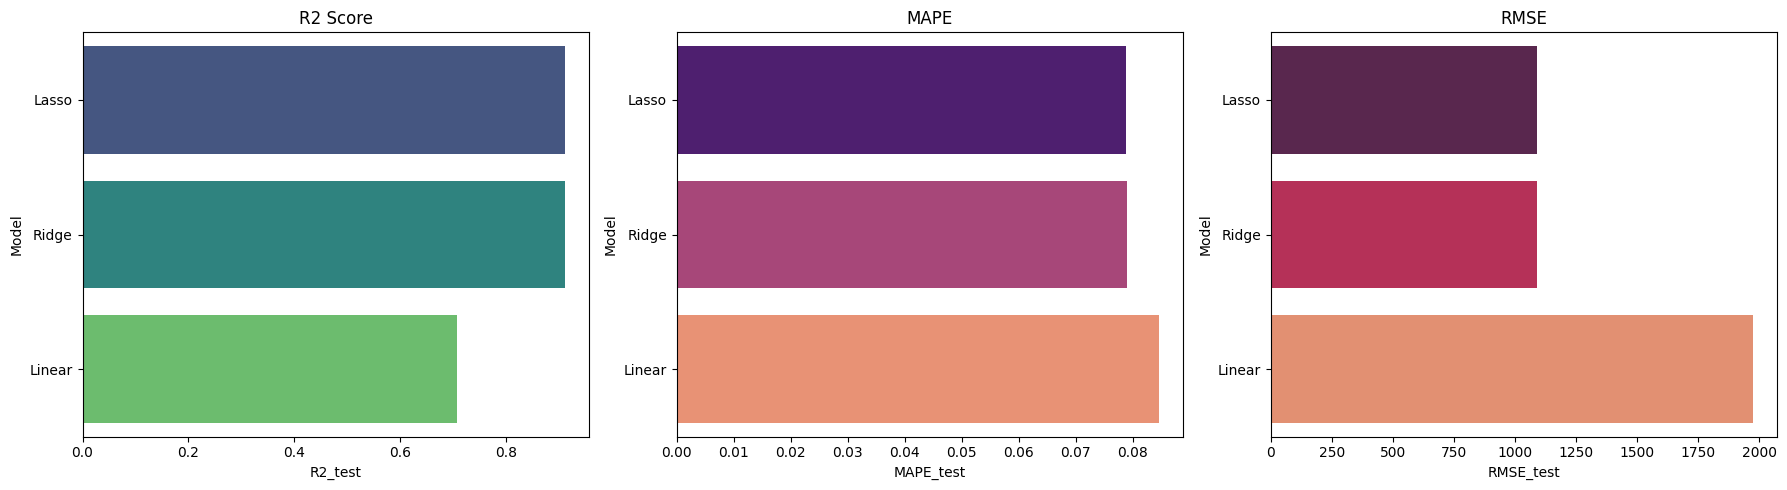

In [247]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x='R2_test', y='Model', data=results.sort_values('R2_test', ascending=False), ax=axes[0], palette='viridis')
axes[0].set_title('R2 Score')

sns.barplot(x='MAPE_test', y='Model', data=results.sort_values('MAPE_test'), ax=axes[1], palette='magma')
axes[1].set_title('MAPE')

sns.barplot(x='RMSE_test', y='Model', data=results.sort_values('RMSE_test'), ax=axes[2], palette='rocket')
axes[2].set_title('RMSE')

plt.tight_layout()
plt.show()

**Выводы:**

**Какая модель лучше?** Самой лучшей моделью оказалась Lasso (по всем метрикам),Ridge имеет практически такие же результаты, разница минимальна. Обе значительно превосходят базовую линейную регрессию, где явно видно переобучение

**Насколько хорошие результаты?** R² = 0.91 - модель объясняет 91% дисперсии цены. MAPE ~7.9% — в среднем ошибка предсказания составляет менее 8% от реальной цены (неплохой результат для задачи предсказания цены). RMSE ~1090 при средней цене ~10730 - тоже хорошо.

**чем докажу, что нет переобучения?:** 
- У Ridge и Lasso разница R² между train и test минимальна, что говорит о хорошей обобщающей способности (нет переобучения); результаты кроссвалидации также подтверждают качество треин/тест разделения. 
- Базовая линейная регрессия, как уже сказал, переобучилась: R² train = 0.934 при R² test = 0.707 — разрыв в 0.23 показывает, что без регуляризации PolynomialFeatures(degree=2) создаёт слишком много признаков и модель запоминает шум.